<a href="https://colab.research.google.com/github/lucasvazelle/nexialog_challlenge/blob/main/Model_IsolationForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -lh "/content/drive/MyDrive/nexialog"

ls: /content/drive/MyDrive/nexialog: No such file or directory
lrw------- 1 root root 0 Apr  8 23:29 /content/drive/MyDrive/nexialog -> /content/drive/.shortcut-targets-by-id/1d-uDDNs_H3Y977kY4F9A0elEoUKUxyz6/nexialog


In [4]:
# Chemin
file_path = "/content/drive/MyDrive/nexialog/data_aggrege_PEAG.parquet"

# Lire le fichier Parquet
data_agrege_S3 = pd.read_parquet(file_path)

# Columns
data_agrege_S3.columns

Index(['peag_nro', 'date_hour', 'code_departement', 'olt_model', 'olt_name',
       'boucle', 'dsp', 'pop_dns', 'nb_test_dns', 'avg_dns_time',
       'std_dns_time', 'nb_test_scoring', 'avg_latence_scoring',
       'std_latence_scoring', 'avg_score_scoring', 'std_score_scoring',
       'nb_client_total', 'moment_journee', 'depts_egaux', 'meme_region',
       'missing_avg_dns_time', 'missing_std_dns_time',
       'missing_avg_latence_scoring', 'missing_std_latence_scoring',
       'missing_avg_score_scoring', 'missing_std_score_scoring', 'type_boucle',
       'type_olt_model', 'encodage_heure_sin', 'encodage_heure_cos',
       'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end'],
      dtype='object')

In [5]:
data_agrege_S3.head(5)

,peag_nro,date_hour,code_departement,olt_model,olt_name,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,missing_std_latence_scoring,missing_avg_score_scoring,missing_std_score_scoring,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end
0,01_peag_1,2024-12-01 00:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,61,4.888439,...,0,0,0,BU,old,0.000000,1.000000,-0.781831,0.62349,True
1,01_peag_1,2024-12-01 01:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,58,5.293034,...,0,0,0,BU,old,0.258819,0.965926,-0.781831,0.62349,True
2,01_peag_1,2024-12-01 02:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,67,5.103739,...,0,0,0,BU,old,0.500000,0.866025,-0.781831,0.62349,True
3,01_peag_1,2024-12-01 03:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,40,5.342719,...,0,0,0,BU,old,0.707107,0.707107,-0.781831,0.62349,True
4,01_peag_1,2024-12-01 04:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,50,4.997415,...,0,0,0,BU,old,0.866025,0.500000,-0.781831,0.62349,True


In [6]:
import psutil

def check_ram_usage():
    # Affiche l'utilisation actuelle de la RAM en Mo
    mem = psutil.virtual_memory()
    print(f"RAM utilisée : {mem.used // (1024 ** 2)} Mo / {mem.total // (1024 ** 2)} Mo")

check_ram_usage()

RAM utilisée : 2706 Mo / 85480 Mo


# IsolationForest - contamination=0.05 - très sensif

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_anomalies_isoforest(df, test_type='dns', contamination=0.05, random_state=42):
    """
    Détecte les anomalies avec Isolation Forest

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        contamination: proportion estimée d’anomalies dans les données
        random_state: pour la reproductibilité

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    # Définir les colonnes spécifiques selon le type de test
    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Caractéristiques temporelles à inclure dans le modèle
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Filtrer les colonnes qui existent réellement dans le DataFrame
    features = required_cols + time_features
    existing_features = [col for col in features if col in df.columns]

    # Préparer les données en supprimant les lignes avec valeurs manquantes
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    # Vérifier que les données ne sont pas vides après nettoyage
    if df_clean.empty:
        return None

    # Standardiser les données pour l'algorithme
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer le modèle Isolation Forest
    model = IsolationForest(contamination=contamination, random_state=random_state)
    df_clean[prefix] = model.fit_predict(X_scaled)

    # Les valeurs -1 sont des anomalies, 1 sont normales
    return df_clean

In [ ]:
# Appliquer le modèle pour chaque type de test
df_anomaly_dns = detect_anomalies_isoforest(data_agrege_S3, test_type='dns')
df_anomaly_score = detect_anomalies_isoforest(data_agrege_S3, test_type='scoring')
df_anomaly_latence = detect_anomalies_isoforest(data_agrege_S3, test_type='latence')

In [ ]:
import matplotlib.pyplot as plt

def visualize_isolationforest_anomalies(data, peag_test, test_type='dns'):
    """
    Visualise les anomalies détectées par Isolation Forest pour un PEAG et un type de test.

    Args:
        data: DataFrame complet (ex: data_agrege_S3)
        peag_test: identifiant PEAG à filtrer
        test_type: 'dns', 'scoring', ou 'latence'
    """

    # Filtrer le PEAG
    df_peag = data[data['peag_nro'] == peag_test]

    # Appliquer Isolation Forest
    df_anomalies = detect_anomalies_isoforest(df_peag, test_type=test_type)

    if df_anomalies is not None:
        # Déterminer la colonne d'anomalie et la colonne de valeur à tracer
        if test_type == 'dns':
            anomaly_col = 'anomaly_dns'
            value_col = 'avg_dns_time'
        elif test_type == 'scoring':
            anomaly_col = 'anomaly_scoring'
            value_col = 'avg_score_scoring'
        elif test_type == 'latence':
            anomaly_col = 'anomaly_latence'
            value_col = 'avg_latence_scoring'
        else:
            print("Type de test invalide.")
            return

        # Compter les anomalies
        anomaly_count = sum(df_anomalies[anomaly_col] == -1)
        print(f"Nombre total de points {test_type}: {len(df_anomalies)}")
        print(f"Nombre d'anomalies {test_type}: {anomaly_count} ({anomaly_count/len(df_anomalies)*100:.2f}%)")

        # Tracer le graphique
        plt.figure(figsize=(12, 5))
        plt.plot(df_anomalies['date_hour'], df_anomalies[value_col], label=value_col)
        plt.scatter(
            df_anomalies['date_hour'][df_anomalies[anomaly_col] == -1],
            df_anomalies[value_col][df_anomalies[anomaly_col] == -1],
            color='red', label='Anomalies'
        )
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.title(f"{peag_test} – {test_type.capitalize()} – Isolation Forest - Contamination=0.05")
        plt.show()
    else:
        print(f"Aucune donnée {test_type} exploitable pour {peag_test}")

Nombre total de points dns: 1488
Nombre d'anomalies dns: 75 (5.04%)


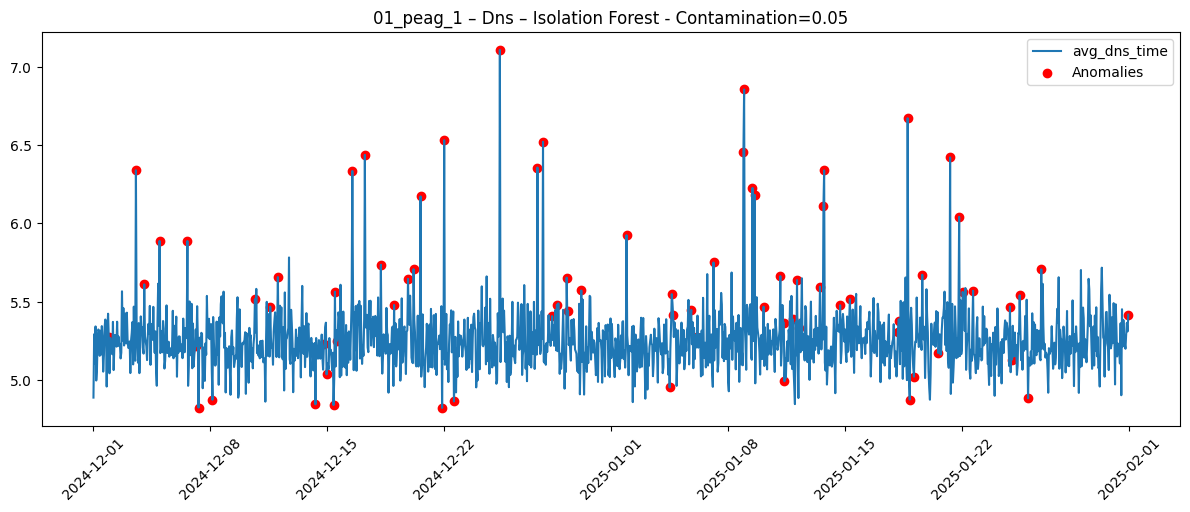

In [ ]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='dns')

In [ ]:
# Avec plotly

import plotly.graph_objects as go

def visualize_isolationforest_anomalies_plotly(data, peag_test, test_type='dns'):
    """
    Visualise les anomalies détectées par Isolation Forest pour un PEAG, avec Plotly (graphique interactif).

    Args:
        data: DataFrame complet (ex: data_agrege_S3)
        peag_test: identifiant PEAG à filtrer
        test_type: 'dns', 'scoring', ou 'latence'
    """

    # Filtrer le PEAG
    df_peag = data[data['peag_nro'] == peag_test]

    # Appliquer Isolation Forest
    df_anomalies = detect_anomalies_isoforest(df_peag, test_type=test_type)

    if df_anomalies is not None:
        # Déterminer la colonne d'anomalie et la valeur à tracer
        if test_type == 'dns':
            anomaly_col = 'anomaly_dns'
            value_col = 'avg_dns_time'
        elif test_type == 'scoring':
            anomaly_col = 'anomaly_scoring'
            value_col = 'avg_score_scoring'
        elif test_type == 'latence':
            anomaly_col = 'anomaly_latence'
            value_col = 'avg_latence_scoring'
        else:
            print("Type de test invalide.")
            return

        # Compter les anomalies
        anomaly_count = sum(df_anomalies[anomaly_col] == -1)
        total_count = len(df_anomalies)
        print(f"Nombre total de points {test_type}: {total_count}")
        print(f"Nombre d'anomalies {test_type}: {anomaly_count} ({anomaly_count/total_count*100:.2f}%)")

        # Créer la figure interactive
        fig = go.Figure()

        # Trace ligne principale
        fig.add_trace(go.Scatter(
            x=df_anomalies['date_hour'],
            y=df_anomalies[value_col],
            mode='lines+markers',
            name=value_col,
            line=dict(color='blue'),
            hovertemplate='Date: %{x}<br>Valeur: %{y:.2f}'
        ))

        # Trace anomalies
        df_anomaly_pts = df_anomalies[df_anomalies[anomaly_col] == -1]
        fig.add_trace(go.Scatter(
            x=df_anomaly_pts['date_hour'],
            y=df_anomaly_pts[value_col],
            mode='markers',
            name='Anomalies',
            marker=dict(color='red', size=8, symbol='x'),
            hovertemplate='Date: %{x}<br>Anomalie: %{y:.2f}'
        ))

        # Mise en forme
        fig.update_layout(
            title=f"{peag_test} – {test_type.capitalize()} – Isolation Forest (Interactif)",
            xaxis_title="Heure",
            yaxis_title=value_col,
            xaxis=dict(tickangle=45),
            hovermode='closest',
            height=500
        )

        fig.show()
    else:
        print(f"Aucune donnée {test_type} exploitable pour {peag_test}")

visualize_isolationforest_anomalies_plotly(data_agrege_S3, peag_test="01_peag_1", test_type="dns")

Nombre total de points dns: 1488
Nombre d'anomalies dns: 75 (5.04%)


Nombre total de points scoring: 1488
Nombre d'anomalies scoring: 75 (5.04%)


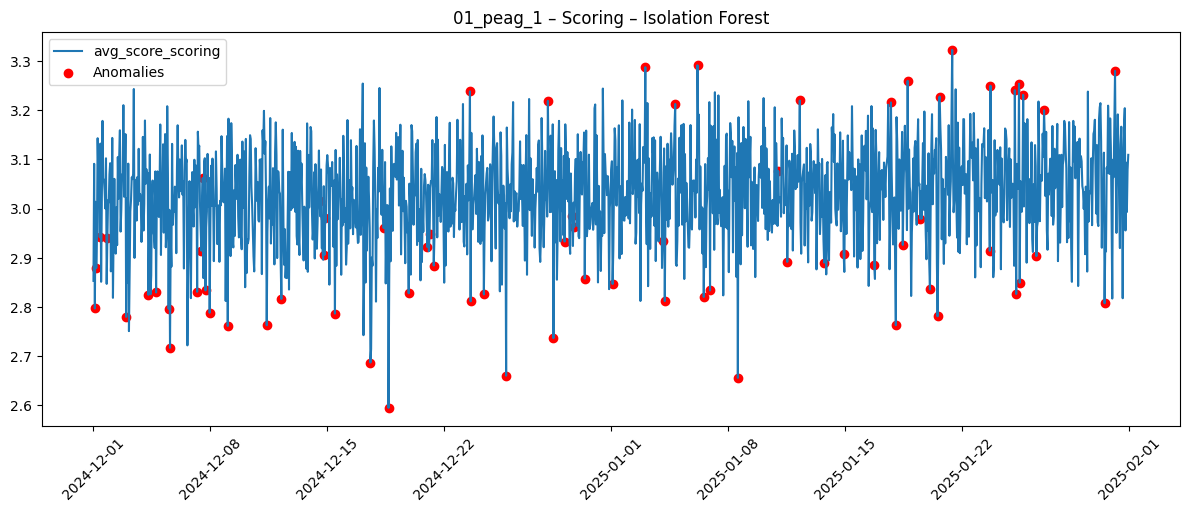

In [ ]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='scoring')

Nombre total de points latence: 1488
Nombre d'anomalies latence: 75 (5.04%)


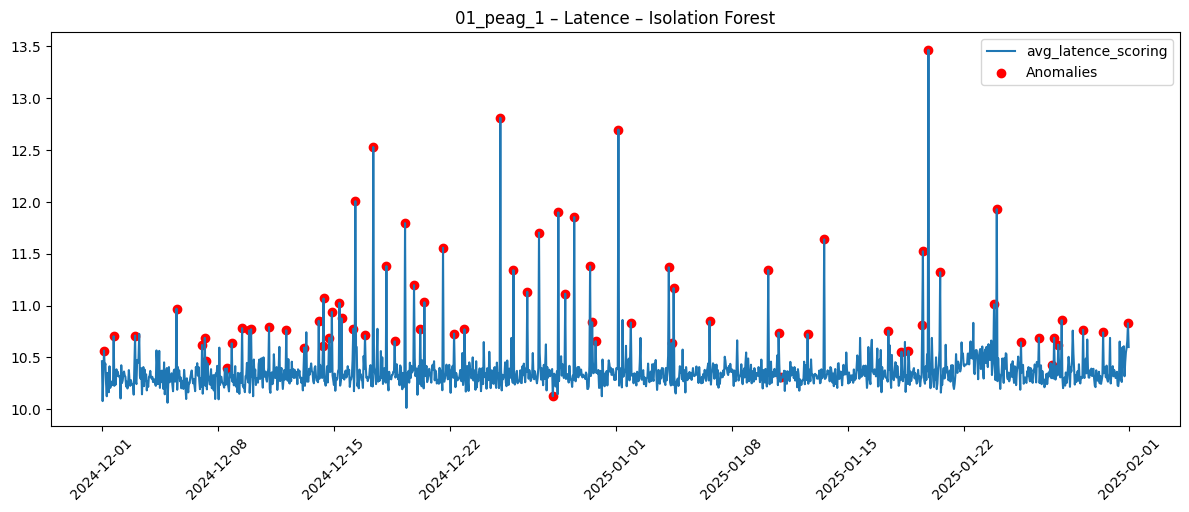

In [ ]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='latence')

# IsolationForest - contamination=0.03 - moins sensif

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_anomalies_isoforest(df, test_type='dns', contamination=0.03, random_state=42, verbose=False):
    """
    Détecte les anomalies avec Isolation Forest

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        contamination: proportion estimée d’anomalies dans les données
        random_state: pour la reproductibilité
        verbose: si True, affiche les informations de debug

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    if verbose:
        print(f"\n=== Détection des anomalies pour test_type = {test_type} ===")

    # Définir les colonnes spécifiques selon le type de test
    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Caractéristiques temporelles à inclure dans le modèle
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Filtrer les colonnes qui existent réellement dans le DataFrame
    features = required_cols + time_features
    existing_features = [col for col in features if col in df.columns]

    if verbose:
        print(f"→ Features utilisées ({len(existing_features)}): {existing_features}")

    # Préparer les données en supprimant les lignes avec valeurs manquantes
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    if verbose:
        print(f"→ Données après dropna: {df_clean.shape[0]} lignes")

    # Vérifier que les données ne sont pas vides après nettoyage
    if df_clean.empty:
        if verbose:
            print("⚠️ Données vides après nettoyage, abandon.")
        return None

    if verbose:
        print("→ Statistiques descriptives des colonnes utilisées:")
        print(df_clean[existing_features].describe().transpose().round(2))

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer Isolation Forest
    model = IsolationForest(contamination=contamination, random_state=random_state)
    df_clean[prefix] = model.fit_predict(X_scaled)

    return df_clean

In [ ]:
# Appliquer le modèle pour chaque type de test
df_anomaly_dns = detect_anomalies_isoforest(data_agrege_S3, test_type='dns')
df_anomaly_score = detect_anomalies_isoforest(data_agrege_S3, test_type='scoring')
df_anomaly_latence = detect_anomalies_isoforest(data_agrege_S3, test_type='latence')


=== Détection des anomalies pour test_type = dns ===
→ Features utilisées (8): ['nb_test_dns', 'avg_dns_time', 'std_dns_time', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 2384134 lignes
→ Statistiques descriptives des colonnes utilisées:
                               count   mean    std   min    25%    50%    75%  \
nb_test_dns                2384134.0  53.52  85.64  5.00  16.00  28.00  58.00   
avg_dns_time               2384134.0   4.31   2.15  0.86   2.79   3.88   5.32   
std_dns_time               2384134.0   0.79   1.87  0.03   0.40   0.55   0.82   
encodage_heure_sin         2384134.0  -0.00   0.71 -1.00  -0.71   0.00   0.71   
encodage_heure_cos         2384134.0  -0.00   0.71 -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  2384134.0   0.01   0.70 -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  2384134.0   0.00   0.71 -0.90  -0.90  -0.22   0.62   

                  


=== Détection des anomalies pour test_type = dns ===
→ Features utilisées (8): ['nb_test_dns', 'avg_dns_time', 'std_dns_time', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 1488 lignes
→ Statistiques descriptives des colonnes utilisées:
                            count   mean    std    min    25%    50%    75%  \
nb_test_dns                1488.0  61.57  11.22  25.00  54.00  61.00  69.00   
avg_dns_time               1488.0   5.26   0.20   4.82   5.14   5.24   5.34   
std_dns_time               1488.0   1.19   0.91   0.74   0.98   1.05   1.14   
encodage_heure_sin         1488.0  -0.00   0.71  -1.00  -0.71   0.00   0.71   
encodage_heure_cos         1488.0  -0.00   0.71  -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  1488.0   0.02   0.70  -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  1488.0   0.00   0.71  -0.90  -0.90  -0.22   0.62   

                              max  
n

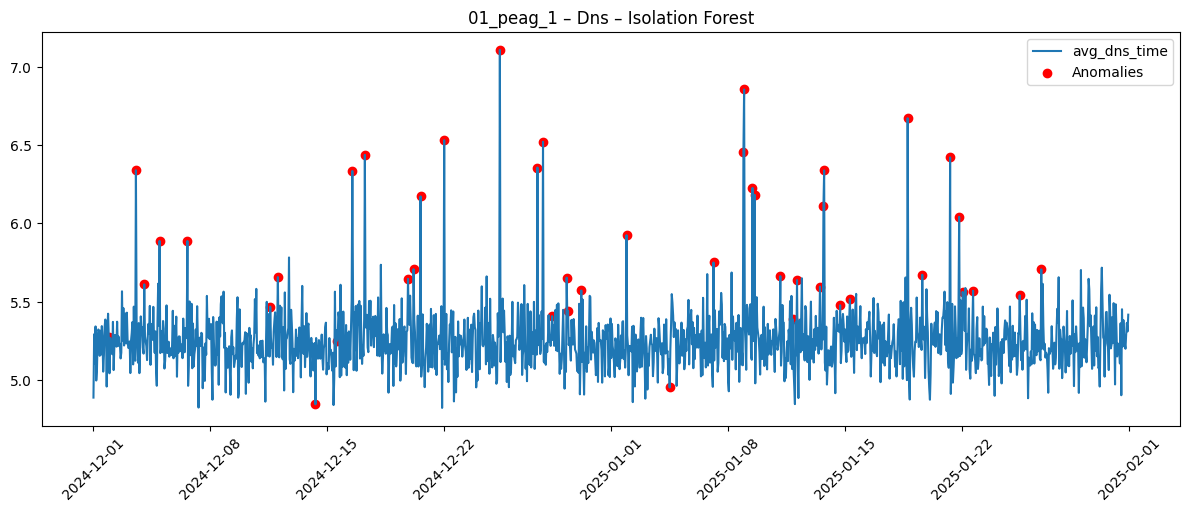

In [ ]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='dns')


=== Détection des anomalies pour test_type = scoring ===
→ Features utilisées (8): ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 1488 lignes
→ Statistiques descriptives des colonnes utilisées:
                            count   mean   std    min    25%    50%    75%  \
nb_test_scoring            1488.0  30.84  5.68  16.00  27.00  31.00  35.00   
avg_score_scoring          1488.0   3.03  0.10   2.59   2.97   3.03   3.10   
std_score_scoring          1488.0   0.52  0.09   0.34   0.45   0.51   0.59   
encodage_heure_sin         1488.0  -0.00  0.71  -1.00  -0.71   0.00   0.71   
encodage_heure_cos         1488.0  -0.00  0.71  -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  1488.0   0.02  0.70  -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  1488.0   0.00  0.71  -0.90  -0.90  -0.22   0.62   

                           

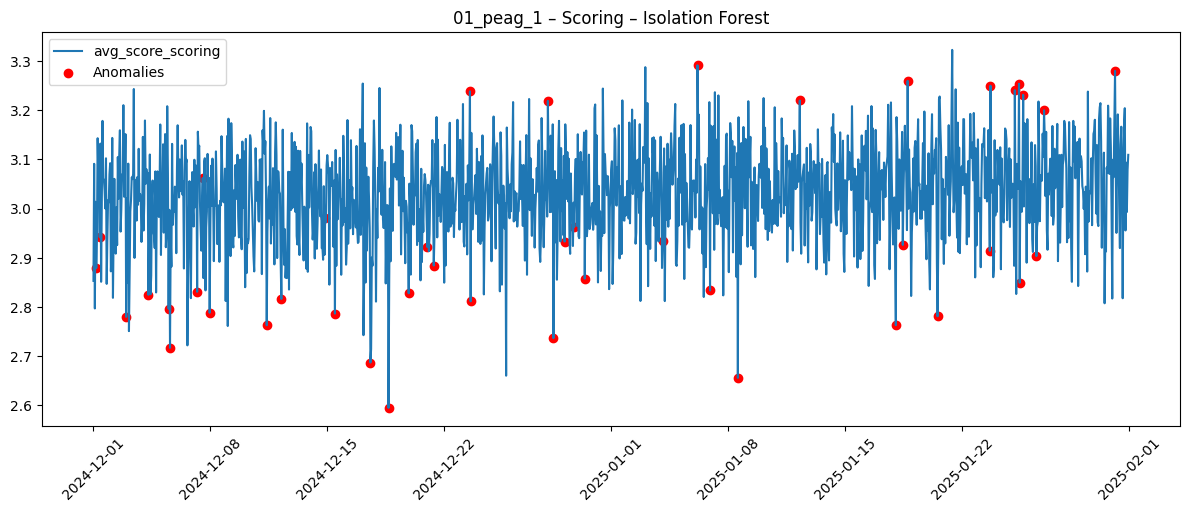

In [ ]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='scoring')


=== Détection des anomalies pour test_type = latence ===
→ Features utilisées (8): ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 1488 lignes
→ Statistiques descriptives des colonnes utilisées:
                            count   mean   std    min    25%    50%    75%  \
nb_test_scoring            1488.0  30.84  5.68  16.00  27.00  31.00  35.00   
avg_latence_scoring        1488.0  10.37  0.22  10.01  10.28  10.33  10.40   
std_latence_scoring        1488.0   0.62  1.06   0.22   0.34   0.39   0.47   
encodage_heure_sin         1488.0  -0.00  0.71  -1.00  -0.71   0.00   0.71   
encodage_heure_cos         1488.0  -0.00  0.71  -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  1488.0   0.02  0.70  -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  1488.0   0.00  0.71  -0.90  -0.90  -0.22   0.62   

                       

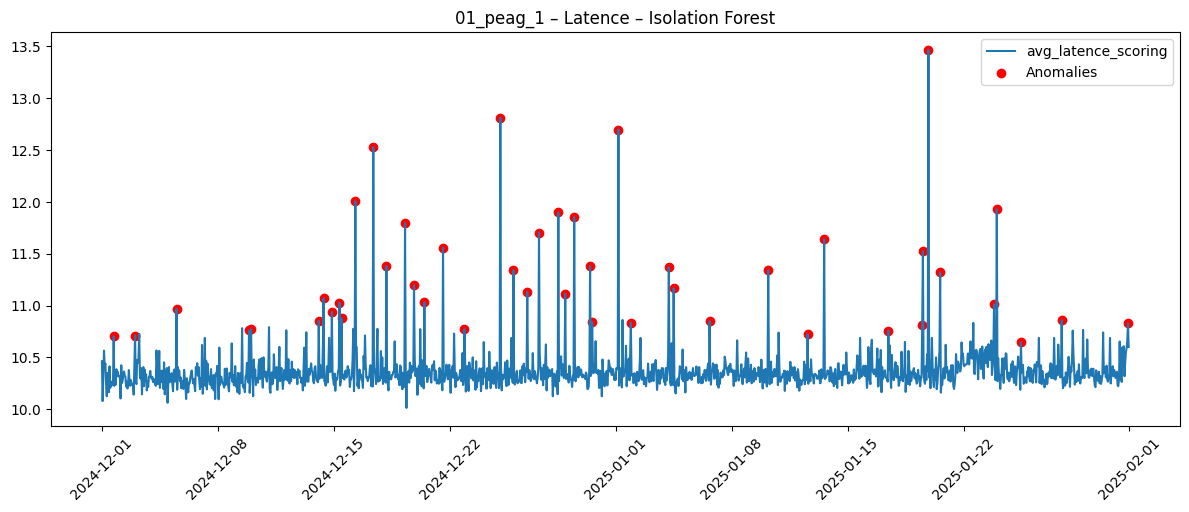

In [ ]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='latence')

In [ ]:
def add_isolationforest_anomaly_columns(df, test_types=['dns', 'scoring', 'latence'], contamination=0.03):
    """
    Applique Isolation Forest à chaque PEAG pour plusieurs types de test,
    et ajoute les colonnes d'anomalies au DataFrame.

    Args:
        df: DataFrame d'entrée (doit contenir 'peag_nro' et 'date_hour')
        test_types: liste des types de test à traiter
        contamination: paramètre de contamination pour Isolation Forest

    Returns:
        DataFrame avec colonnes 'is_anomaly_<type>'
    """

    # Initialiser la copie du dataframe d'origine
    df_result = df.copy()

    # Parcourir chaque PEAG unique
    for peag in df_result['peag_nro'].unique():
        print(f"Traitement de l'OLT: {peag}")
        df_peag = df_result[df_result['peag_nro'] == peag]

        for test_type in test_types:
            print(f"  Type de test: {test_type}")
            df_anomalies = detect_anomalies_isoforest(
                df_peag, test_type=test_type, contamination=contamination, verbose=False
            )

            if df_anomalies is None:
                print("    Aucune donnée exploitable")
                continue

            anomaly_col = f"anomaly_{test_type}"
            flag_col = f"is_anomaly_{test_type}"

            df_anomalies[flag_col] = (df_anomalies[anomaly_col] == -1).astype(int)
            n_anomaly = df_anomalies[flag_col].sum()
            pourcent = n_anomaly / len(df_anomalies) * 100
            print(f"    Anomalies: {n_anomaly} ({pourcent:.2f}%)")

            df_result.loc[
                df_result['date_hour'].isin(df_anomalies['date_hour']) &
                (df_result['peag_nro'] == peag), flag_col
            ] = df_anomalies[flag_col].values

    # Remplacer les NaN par 0
    for test_type in test_types:
        col = f"is_anomaly_{test_type}"
        if col not in df_result.columns:
            df_result[col] = 0
        else:
            df_result[col] = df_result[col].fillna(0).astype(int)

    return df_result

In [ ]:
# Définir un sous-ensemble pour tester
peags_test = ["01_peag_1"]
df_test = data_agrege_S3[data_agrege_S3['peag_nro'].isin(peags_test)]

# Appliquer Isolation Forest pour chaque test_type
df_with_anomalies = add_isolationforest_anomaly_columns(df_test, test_types=['dns', 'scoring', 'latence'], contamination=0.01)

# Résumé global
print("\nRésultats globaux:")
print(f"Nombre d'anomalies DNS: {df_with_anomalies['is_anomaly_dns'].sum()}")
print(f"Nombre d'anomalies Scoring: {df_with_anomalies['is_anomaly_scoring'].sum()}")
print(f"Nombre d'anomalies Latence: {df_with_anomalies['is_anomaly_latence'].sum()}")

Traitement de l'OLT: 01_peag_1
  Type de test: dns
    Anomalies: 15 (1.01%)
  Type de test: scoring
    Anomalies: 15 (1.01%)
  Type de test: latence
    Anomalies: 15 (1.01%)

Résultats globaux:
Nombre d'anomalies DNS: 15
Nombre d'anomalies Scoring: 15
Nombre d'anomalies Latence: 15


# Comparaison entre DBScan et IsolationForest (0.03)

## Comparaison technique : Isolation Forest vs DBSCAN

| Critère                              | Isolation Forest                                         | DBSCAN (Density-Based Spatial Clustering)               |
|-------------------------------------|----------------------------------------------------------|----------------------------------------------------------|
| **Type d’algorithme**               | Méthode d’ensemble basée sur des arbres aléatoires       | Clustering basé sur la densité locale                    |
| **Approche**                        | Apprentissage non supervisé, détection de valeurs atypiques | Clustering sans supervision, identifie les "bruits"     |
| **Hypothèse de base**              | Les anomalies sont plus faciles à isoler que les points normaux | Les points anormaux sont dans des régions de faible densité |
| **Paramètres clés**                | `contamination` (taux d'anomalies estimé), `n_estimators` | `eps` (rayon), `min_samples` (densité minimale)         |
| **Échelle des données**            | Nécessite une standardisation des variables              | Sensible à l’échelle, nécessite souvent une normalisation |
| **Performances sur grands jeux**   | Très scalable (complexité quasi-linéaire)                | Moins scalable, surtout avec des données à forte dimension |
| **Forme des données supportée**    | Toutes formes, sans hypothèse sur la distribution        | Efficace surtout pour les clusters de forme arbitraire   |
| **Sensibilité aux paramètres**     | Moins sensible si `contamination` est bien choisi        | Très sensible à `eps` et `min_samples`                   |
| **Capacité de généralisation**     | Modèle peut être réutilisé sur de nouvelles données      | Pas de généralisation directe, modèle statique           |
| **Explicabilité / Interprétation** | Difficile à interpréter directement                      | Interprétable via la structure des clusters et les bruits |
| **Données bruitées**               | Tolérant, isole bien les points aberrants                | Peut mal réagir aux données bruitées proches des clusters |
| **Cas d'usage typiques**           | Détection d’anomalies, fraudes, maintenance préventive   | Regroupement spatial, détection de zones à faible densité |



## Un exemple de 01_peag_1

In [7]:
def detect_anomalies_dbscan(df, test_type='dns', eps=3, min_samples=4):
    """
    Détecte les anomalies avec DBSCAN

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        eps: Paramètre eps pour DBSCAN
        min_samples: Paramètre min_samples pour DBSCAN

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Ajouter les caractéristiques temporelles
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Combiner les features
    features = required_cols + time_features

    existing_features = [col for col in features if col in df.columns]

    # Nettoyer les données
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    if df_clean.empty:
        return None

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer DBSCAN
    model = DBSCAN(eps=eps, min_samples=min_samples)
    df_clean[prefix] = model.fit_predict(X_scaled)

    return df_clean

In [9]:
peag_test = "01_peag_1"
df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test]

# Détection DBSCAN
df_anomalies_dbscan = detect_anomalies_dbscan(df_peag, test_type='dns', eps=3, min_samples=4)

# Détection Isolation Forest
df_anomalies_iso = detect_anomalies_isoforest(df_peag, test_type='dns', contamination=0.01)

In [ ]:
df_compare = df_anomalies_iso[['date_hour', 'avg_dns_time', 'anomaly_dns']].copy()
df_compare = df_compare.rename(columns={'anomaly_dns': 'iso_anomaly'})

df_compare = df_compare.merge(
    df_anomalies_dbscan[['date_hour', 'avg_dns_time', 'anomaly_dns']].rename(columns={'anomaly_dns': 'dbscan_anomaly'}),
    on='date_hour', suffixes=('', '_dbscan')
)

In [ ]:
def classify_case(row):
    if row['iso_anomaly'] == -1 and row['dbscan_anomaly'] == -1:
        return 'IsoF & DBSCAN'
    elif row['iso_anomaly'] == -1:
        return 'IsoF only'
    elif row['dbscan_anomaly'] == -1:
        return 'DBSCAN only'
    else:
        return 'Normal'

df_compare['anomaly_case'] = df_compare.apply(classify_case, axis=1)

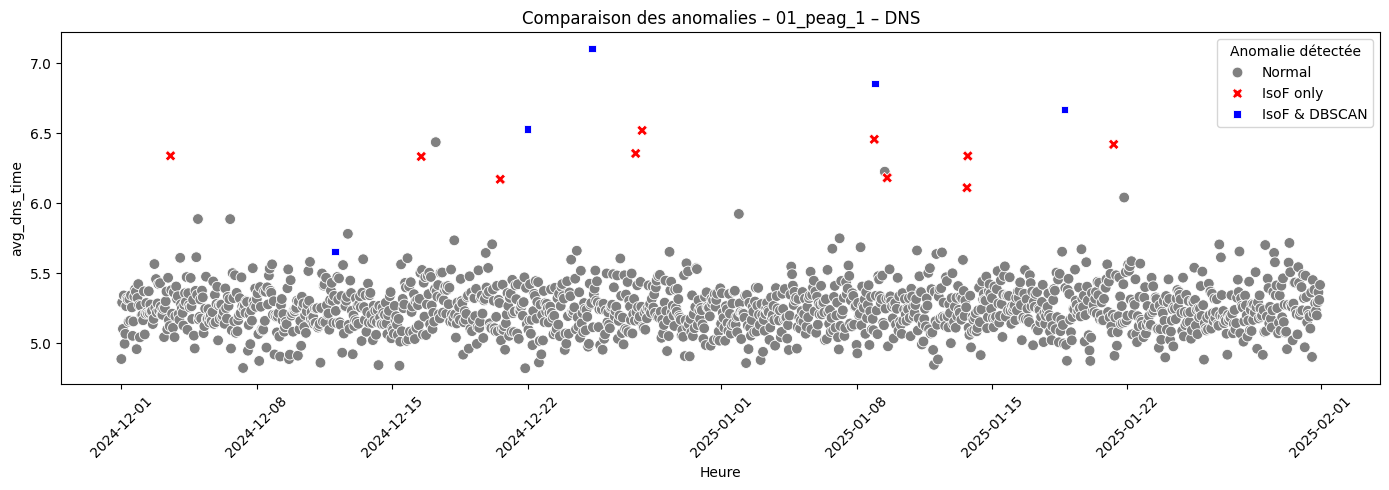

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
sns.scatterplot(
    data=df_compare,
    x='date_hour',
    y='avg_dns_time',
    hue='anomaly_case',
    palette={
        'Normal': 'grey',
        'IsoF only': 'red',
        'DBSCAN only': 'orange',
        'IsoF & DBSCAN': 'blue'
    },
    style='anomaly_case',
    s=60
)

plt.title(f"Comparaison des anomalies – {peag_test} – DNS")
plt.xlabel("Heure")
plt.ylabel("avg_dns_time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Anomalie détectée")
plt.show()

# Interprétabilité

## Sans ML - Andersel et Al

### Modèle Andersel et Al - OLT

In [ ]:
test =["avg_dns_time", "avg_latence_scoring", "avg_score_scoring"]

In [ ]:
from scipy import stats
import numpy as np

def detect_jumps_andersen(df, window=48, lambda_quantile=0.9999, metrique="avg_dns_time"):
    """
    Détecte les jumps en utilisant la méthode d'Andersen, Bollerslev et Dobrev (2007).

    - window : taille de la fenêtre pour la volatilité locale.
    - lambda_quantile : seuil quantile pour la détection.
    - metrique : nom de la colonne à utiliser ('avg_dns_time', 'avg_score_scoring', etc.)

    Si metrique == 'avg_score_scoring', on utilise la valeur absolue des variations.
    """
    df = df.copy()
    df["log_metric"] = np.log(df[metrique])  # Log pour capturer les variations relatives
    df["diff_log"] = df["log_metric"].diff()

    # Estimation de la volatilité locale (rolling std)
    df["volatility"] = df["diff_log"].rolling(window=window, min_periods=1).std()

    # Choix du type de saut : positif pur ou valeur absolue
    if metrique == "avg_score_scoring":
        # On cherche les sauts significatifs dans les deux sens
        df["stat_jump"] = df["diff_log"].abs() / df["volatility"]
    else:
        # Sauts positifs uniquement
        df["stat_jump"] = df["diff_log"] / df["volatility"]

    # Seuil basé sur la loi normale standard
    jump_threshold = stats.norm.ppf(lambda_quantile)

    # Détection du jump selon le type
    df["is_jump"] = df["stat_jump"] > jump_threshold

    return df

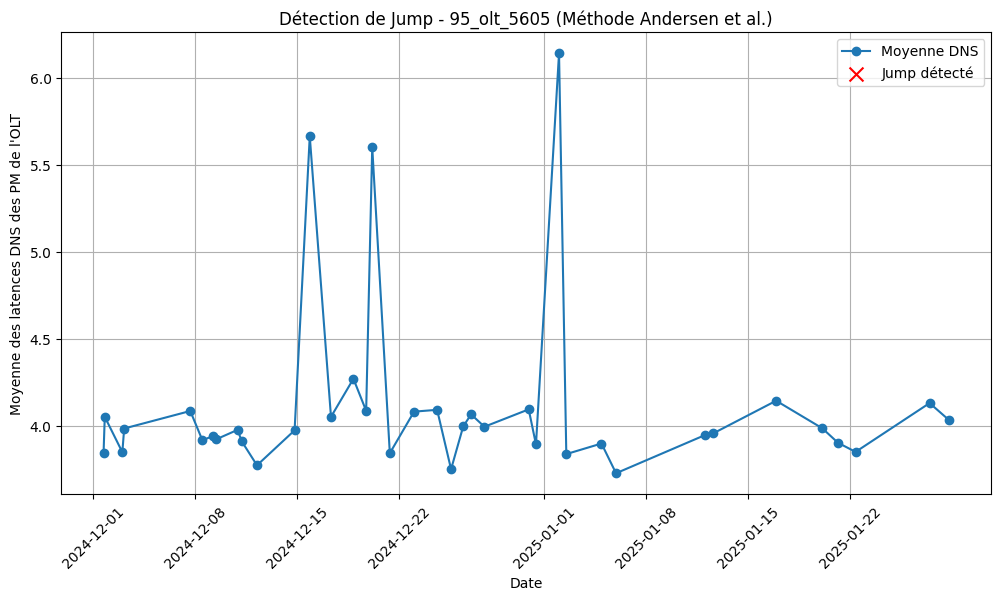

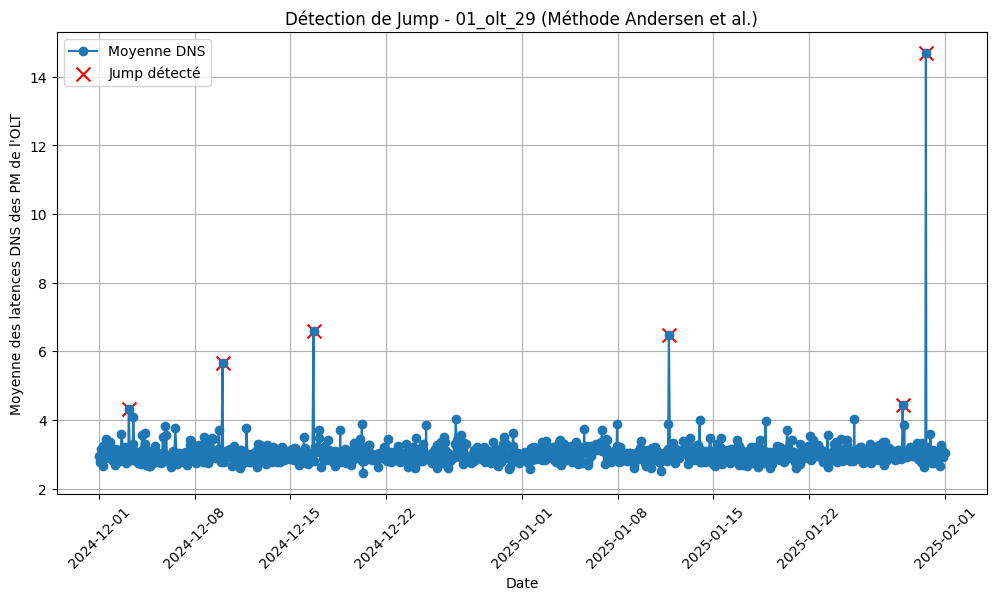

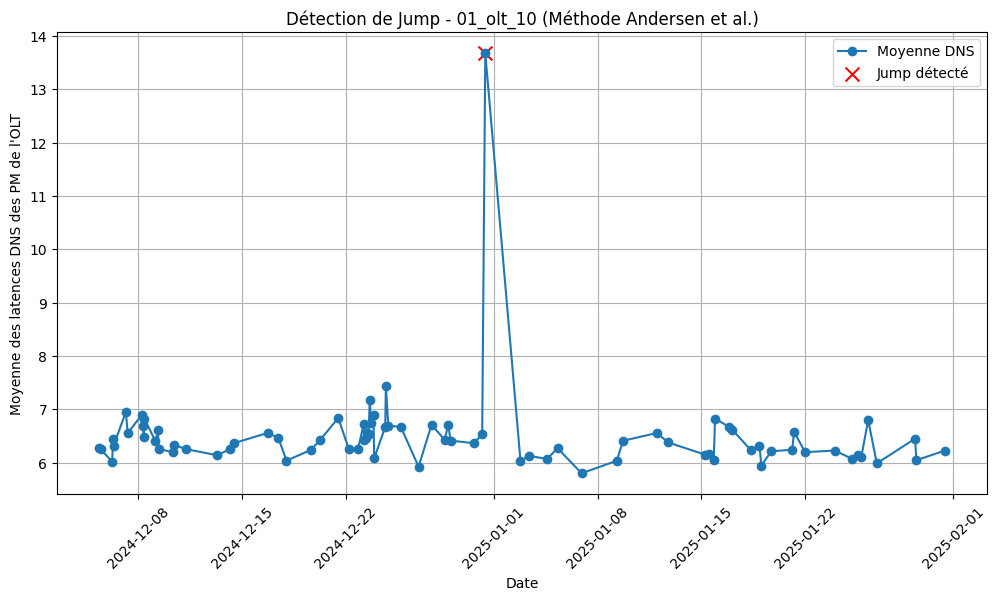

In [ ]:
olt_name_list = ["95_olt_5605", "01_olt_29", "01_olt_10" ] # Remplace par le nom de l'OLT souhaité
metrique = test[0]
for olt_name in olt_name_list:
  df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt_name]

  # Appliquer la détection de jumps
  df_jumps = detect_jumps_andersen(df_olt, lambda_quantile=0.9999, metrique = metrique)

  # Tracer les résultats
  plt.figure(figsize=(12, 6))
  plt.plot(df_olt["date_hour"], df_olt[metrique], label="Moyenne DNS", marker="o", linestyle="-")
  plt.scatter(df_jumps[df_jumps["is_jump"]]["date_hour"], df_jumps[df_jumps["is_jump"]][metrique],
              color="red", label="Jump détecté", marker="x", s=100)
  plt.xlabel("Date")
  plt.ylabel("Moyenne des latences DNS des PM de l'OLT")
  plt.title(f"Détection de Jump - {olt_name} (Méthode Andersen et al.)")
  plt.legend()
  plt.xticks(rotation=45)
  plt.grid()
  plt.show()

### Interprétabilité - Feature Sensitivity Analysis on Metric - OLT

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

def sensitivity_on_metric(df, idx, metrique="avg_dns_time", window=48, lambda_quantile=0.9999,
                          variation_range=np.linspace(-0.5, 0.5, 11)):
    """
    Analyse de sensibilité directe sur la métrique d'origine, avec accès par position (.iloc).
    """
    df_copy = df.copy()
    threshold = stats.norm.ppf(lambda_quantile)
    results = []

    df_copy["log_metric"] = np.log(df_copy[metrique])
    df_copy["diff_log"] = df_copy["log_metric"].diff()
    df_copy["volatility"] = df_copy["diff_log"].rolling(window=window, min_periods=1).std()

    for pct in variation_range:
        test_df = df_copy.copy()

        # Modifier la valeur de metrique à la position idx
        test_df.iloc[idx, test_df.columns.get_loc(metrique)] *= (1 + pct)

        # Recalculer log_metric et diff_log à idx
        test_df.iloc[idx, test_df.columns.get_loc("log_metric")] = np.log(test_df.iloc[idx][metrique])
        if idx > 0:
            test_df.iloc[idx, test_df.columns.get_loc("diff_log")] = (
                test_df.iloc[idx]["log_metric"] - test_df.iloc[idx - 1]["log_metric"]
            )
        else:
            test_df.iloc[idx, test_df.columns.get_loc("diff_log")] = np.nan

        # Recalculer la volatilité locale autour de idx
        start = max(0, idx - window + 1)
        end = idx + 1
        test_df.iloc[idx, test_df.columns.get_loc("volatility")] = test_df["diff_log"].iloc[start:end].std()

        # Calcul final du stat_jump
        stat_jump = test_df.iloc[idx]["diff_log"] / test_df.iloc[idx]["volatility"]
        is_jump = stat_jump > threshold

        results.append({
            "variation_pct": pct,
            "new_metric": test_df.iloc[idx][metrique],
            "new_diff_log": test_df.iloc[idx]["diff_log"],
            "new_volatility": test_df.iloc[idx]["volatility"],
            "stat_jump": stat_jump,
            "is_jump": is_jump
        })

    return pd.DataFrame(results)

In [ ]:
# Liste des noms d'OLT à tester
olt_name_list = ["95_olt_5605", "01_olt_29", "01_olt_10"]

# Stocker tous les résultats ici
liste_resultats = []

# Boucle sur chaque OLT
for olt in olt_name_list:
    # Filtrer le DataFrame pour cet OLT
    df_olt = data_agrege_S3[data_agrege_S3["olt_name"] == olt].copy()

    # Vérifier qu'on a suffisamment de lignes pour faire l'analyse
    if len(df_olt) < 2:
        print(f"Pas assez de données pour {olt}")
        continue

    # Choisir une ligne à analyser : ici, la dernière position valide
    idx_pos = len(df_olt) - 1

    # Appliquer l'analyse de sensibilité
    try:
        result = sensitivity_on_metric(df_olt, idx=idx_pos, metrique="avg_dns_time")
        result["olt_name"] = olt  # Ajouter le nom d'OLT au résultat
        result["position"] = idx_pos  # Pour traçabilité
        liste_resultats.append(result)
    except Exception as e:
        print(f"Erreur avec {olt} : {e}")

# Fusionner tous les résultats
df_sensitivity_all = pd.concat(liste_resultats, ignore_index=True)

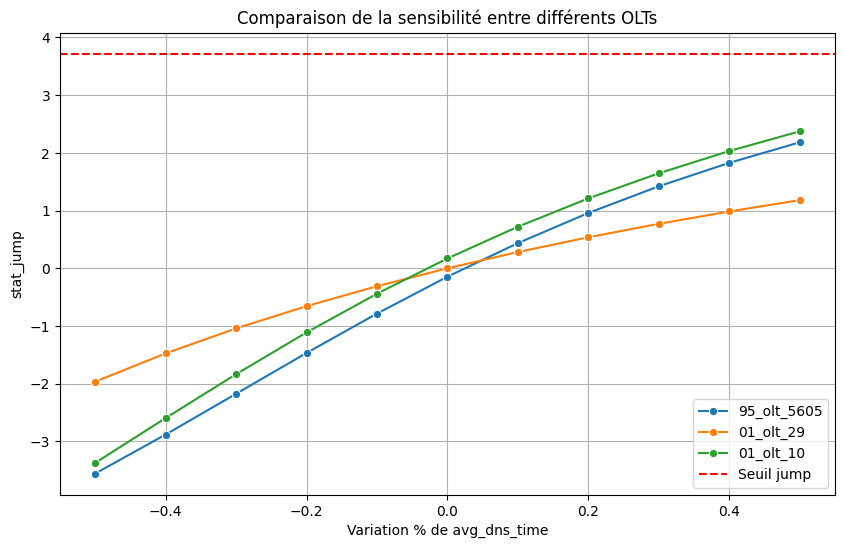

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_sensitivity_all, x="variation_pct", y="stat_jump", hue="olt_name", marker="o")
plt.axhline(stats.norm.ppf(0.9999), color="red", linestyle="--", label="Seuil jump")
plt.title("Comparaison de la sensibilité entre différents OLTs")
plt.xlabel("Variation % de avg_dns_time")
plt.ylabel("stat_jump")
plt.legend()
plt.grid()
plt.show()

**Interprétation ligne par ligne**

---

🔵 `95_olt_5605`

- La courbe est **quasi-linéaire**, partant de ~ **–3.5** et atteignant environ **2.1** quand `avg_dns_time` augmente de **+50%**.

- Cela **ne suffit pas pour déclencher un jump**, même en cas de hausse importante.

- **Plus stable** : il est peu probable qu’un léger changement entraîne une détection de jump.

---

🟠 `01_olt_29`

- La courbe **progresse plus lentement**, et reste en-dessous des autres OLT.

- À **+50%**, la valeur `stat_jump` atteint à peine **~1.1**, soit **loin du seuil critique**.

- Il s’agit de l’OLT avec la **réactivité la plus faible** face aux variations de `avg_dns_time`.

---

🟢 `01_olt_10`

- C’est la **courbe la plus haute** parmi les 3 OLT analysés.

- Elle augmente régulièrement et **dépasse `stat_jump ≈ 2`** lorsque `avg_dns_time` augmente de **+40% à +50%**.

- Cet OLT est **nettement plus sensible** aux variations.

- Il est **potentiellement plus exposé à un jump**, en cas de hausse brutale du temps DNS.



**Tableau comparatif des OLTs selon leur sensibilité au `avg_dns_time`**

| **OLT**        | **Réaction face à l’augmentation de avg_dns_time**        | **Sensibilité** |
|----------------|-----------------------------------------------------------|-----------------|
| `01_olt_10`    | Très réactif, proche du seuil de jump                     | Élevée       |
| `95_olt_5605`  | Progression régulière, mais insuffisante pour un jump     | Moyenne         |
| `01_olt_29`    | La moins réactive, difficile de générer un jump           | Faible          |


## ML - DBScan

### Interprétabilité - Feature contributions - PEAG - test_type='dns'

In [14]:
def analyze_feature_contributions_dbscan(df_detected, test_type="dns"):
    """
    Analyse les moyennes (ou médianes) des features entre normal et anomalie
    pour identifier les variables qui contribuent le plus à la détection.

    Args:
        df_detected : DataFrame retourné par detect_anomalies_dbscan
        test_type : 'dns', 'scoring' ou 'latence'

    Retourne:
        Un DataFrame comparatif entre les clusters -1 (anomalie) et ≠ -1 (normal)
    """
    import numpy as np
    import pandas as pd

    # Déterminer le préfixe selon le type de test
    if test_type == 'dns':
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Vérifier si le préfixe existe
    if prefix not in df_detected.columns:
        raise ValueError(f"Colonne {prefix} non trouvée dans le DataFrame.")

    # Séparer les features (toutes sauf 'date_hour' et prefix cluster)
    features = [col for col in df_detected.columns if col not in ['date_hour', prefix]]

    # Calculer la moyenne (ou mediane) par cluster
    grouped_stats = df_detected.groupby(prefix)[features].agg(['mean', 'median']).T

    # Nettoyer l’index
    grouped_stats.index = ['_'.join(col) for col in grouped_stats.index]

    return grouped_stats

In [15]:
def summarize_dbscan_clusters(df, test_type='dns'):
    """
    Résume les clusters DBSCAN : nombre de points, pourcentage, et interprétation simple.

    Args:
        df : DataFrame contenant le résultat de detect_anomalies_dbscan
        test_type : 'dns', 'scoring' ou 'latence' → utilisé pour détecter le nom de la colonne cluster

    Returns:
        DataFrame résumant les clusters DBSCAN avec nb de points, pourcentage, et description
    """
    import pandas as pd

    # Déterminer le nom de la colonne cluster
    if test_type == 'dns':
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Vérifier que la colonne existe
    if prefix not in df.columns:
        raise ValueError(f"La colonne {prefix} n'existe pas dans le DataFrame.")

    # Compter les points dans chaque cluster
    count_series = df[prefix].value_counts().sort_index()
    total = count_series.sum()
    pct_series = (count_series / total * 100).round(2)

    # Créer le tableau final
    summary = pd.DataFrame({
        "cluster_label": count_series.index,
        "n_points": count_series.values,
        "pct_points (%)": pct_series.values,
    })

    # Ajouter une description simple
    def get_description(label):
        if label == -1:
            return "Anomalie (Outlier)"
        else:
            return f"Cluster normal - Label {label}"

    summary["description"] = summary["cluster_label"].apply(get_description)

    return summary

#### Un exemple de 01_peag_29

In [16]:
# Liste des PEAGs à analyser
peags_test = ["01_peag_29"] # Liste des PEAG

for peag_test in peags_test:
    print(f"Analyse du PEAG : {peag_test}")

    # Étape 0 : Filtrer les données pour ce PEAG
    df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test].copy()

    if df_peag.empty:
        print(f"Aucune donnée pour {peag_test}")
        continue

    # Étape 1 : Appliquer DBSCAN
    df_result = detect_anomalies_dbscan(df=df_peag, test_type="dns")

    if df_result is None:
        print(f"DBSCAN n’a pas pu être appliqué à {peag_test}")
        continue

    # Étape 2 : Résumer les clusters
    df_summary = summarize_dbscan_clusters(df_result, test_type="dns")
    display(df_summary)

    # Étape 3 : Analyse des features par cluster
    stats_features = analyze_feature_contributions_dbscan(df_result, test_type="dns")

    # Étape 4 : Afficher les 10 features les plus discriminantes
    display(stats_features.head(10))

    print("—" * 60)  # Séparation entre PEAGs

Analyse du PEAG : 01_peag_29


,cluster_label,n_points,pct_points (%),description
0,-1,7,1.24,Anomalie (Outlier)
1,0,558,98.76,Cluster normal - Label 0


anomaly_dns,-1,0
nb_test_dns_mean,18.142857,1.381004e+01
nb_test_dns_median,12.000000,1.400000e+01
avg_dns_time_mean,3.883187,2.830032e+00
avg_dns_time_median,4.124475,2.801241e+00
std_dns_time_mean,3.181831,6.004165e-01
std_dns_time_median,3.172145,4.922751e-01
encodage_heure_sin_mean,0.243872,1.745778e-02
encodage_heure_sin_median,0.500000,1.224647e-16
encodage_heure_cos_mean,0.077512,-4.129275e-02
encodage_heure_cos_median,0.258819,-1.836970e-16


————————————————————————————————————————————————————————————


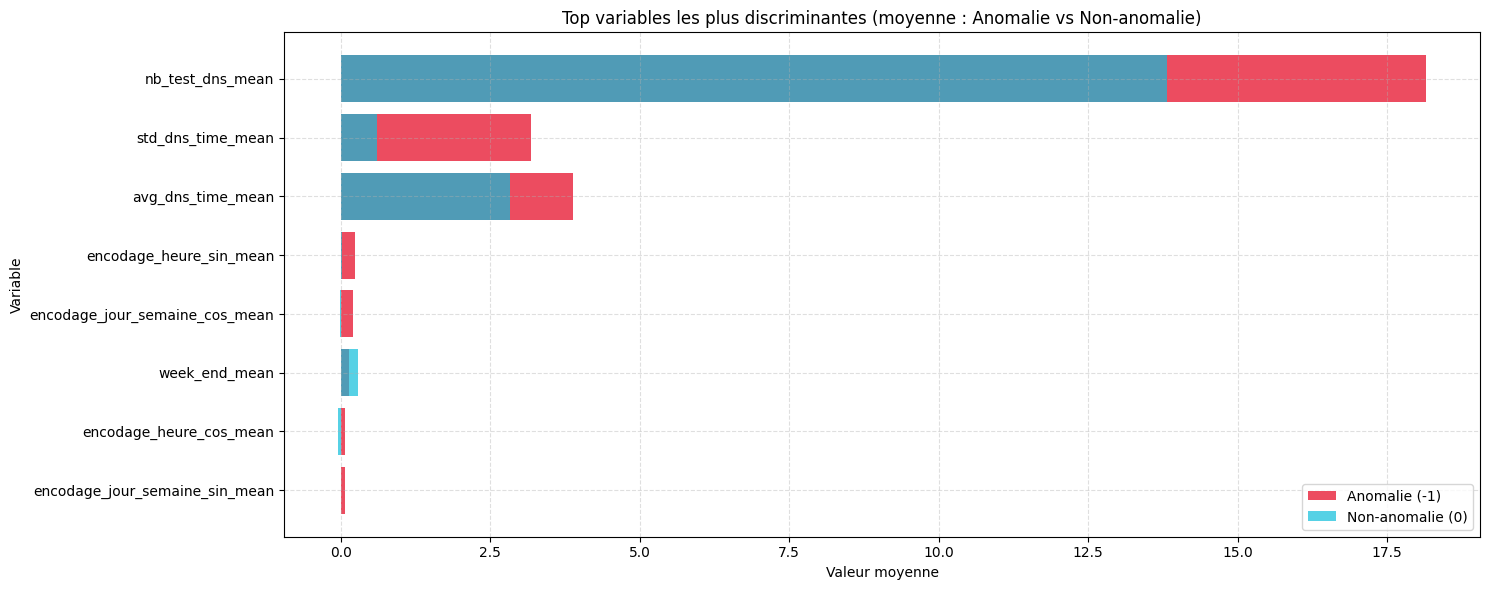

In [19]:
import matplotlib.pyplot as plt

# Étape 1 : Ne garder que les lignes avec des moyennes
mean_only = stats_features[stats_features.index.str.endswith("_mean")].copy()

# Étape 2 : Extraire le cluster -1 (anomalie)
cluster_anomaly = mean_only[-1]

# Étape 3 : Calculer la moyenne de tous les clusters normaux (≠ -1)
cluster_non_anomaly = mean_only[[col for col in mean_only.columns if col != -1]].mean(axis=1)

# Étape 4 : Calculer la différence absolue et trier du plus grand au plus petit
diff = (cluster_anomaly - cluster_non_anomaly).abs().sort_values(ascending=False)
top_features = diff.head(10).index[::-1]  # 🔁 Inverser pour afficher le plus important en haut

# Étape 5 : Préparer le graphique
plt.figure(figsize=(15, 6))

# ✅ Changer les couleurs selon vos codes hex
plt.barh(top_features, cluster_anomaly[top_features], color='#E4001D', alpha=0.7, label='Anomalie (-1)')
plt.barh(top_features, cluster_non_anomaly[top_features], color='#0EBEDB', alpha=0.7, label='Non-anomalie (0)')

# Étape 6 : Mise en forme
plt.title("Top variables les plus discriminantes (moyenne : Anomalie vs Non-anomalie)")
plt.xlabel("Valeur moyenne")
plt.ylabel("Variable")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<ipython-input-69-5655354c1910>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_only["diff_score"] = (mean_only[-1] - mean_only.drop(columns=-1).mean(axis=1)).abs()


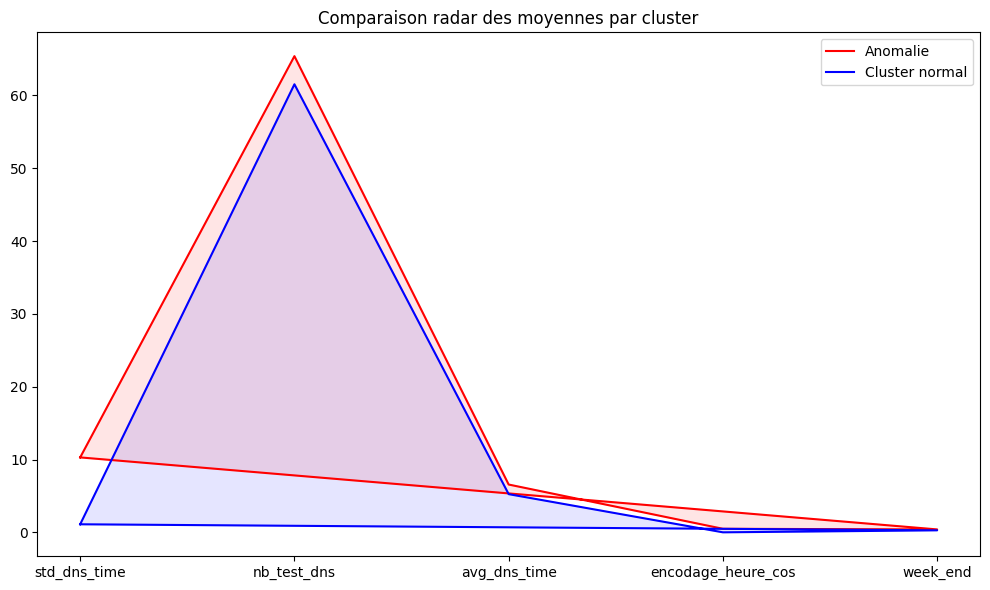

In [ ]:
from math import pi
import pandas as pd
import matplotlib.pyplot as plt

def plot_radar(stats_df, cluster_labels=[-1, 0], N=5):
    """
    Trace un radar chart comparant les moyennes des clusters sur N variables les plus discriminantes.
    Affiche le cluster -1 comme "Anomalie" en rouge, et le cluster 0 comme normal en bleu.
    """
    # Filtrer uniquement les moyennes
    mean_only = stats_df[stats_df.index.str.endswith("_mean")]
    mean_only["diff_score"] = (mean_only[-1] - mean_only.drop(columns=-1).mean(axis=1)).abs()
    top_N = mean_only.sort_values("diff_score", ascending=False).head(N).drop(columns="diff_score")

    # Préparer les données
    df_radar = top_N.T
    df_radar.columns = [name.replace("_mean", "") for name in df_radar.columns]
    categories = list(df_radar.columns)
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]

    # Création du graphique
    plt.figure(figsize=(10, 6))

    for cluster in cluster_labels:
        if cluster in df_radar.index:
            values = df_radar.loc[cluster].tolist() + [df_radar.loc[cluster].tolist()[0]]

            # 🔹 Couleurs personnalisées
            if cluster == -1:
                color = 'red'
                label = "Anomalie"
            elif cluster == 0:
                color = 'blue'
                label = "Cluster normal"
            else:
                color = None
                label = f"Cluster {cluster}"

            plt.plot(angles, values, label=label, color=color)
            plt.fill(angles, values, alpha=0.1, color=color)

    plt.xticks(angles[:-1], categories, size=10)
    plt.title("Comparaison radar des moyennes par cluster")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Appel de la fonction pour visualiser les 5 variables les plus discriminantes
plot_radar(stats_features, cluster_labels=[-1, 0], N=5)

In [ ]:
# Lister les labels de clusters détectés
print(sorted(df_result['anomaly_dns'].unique()))

[np.int64(-1), np.int64(0)]


**Comparaison des moyennes (Radar) : Anomalie vs Cluster normal**

| Variable                    | Anomalie (🔴) | Cluster normal (🔵) | Interprétation                            |
|----------------------------|---------------|----------------------|--------------------------------------------|
| `nb_test_dns`              | 🟢 Plus élevé  | 🟡 Moins élevé        | Les anomalies se produisent lors de nombreux tests DNS |
| `std_dns_time`             | 🔴 Élevé       | 🔵 Très faible        | Forte variation de la latence DNS en anomalie |
| `avg_dns_time`             | 🔴 Plus élevé  | 🔵 Plus bas           | Moyenne DNS plus longue dans les anomalies |
| `encodage_heure_sin`       | 🔶 Léger écart | 🔶 Léger écart        | Peu de différence liée à l’heure sinusoïdale |
| `encodage_jour_semaine_cos`| 🔶 Léger écart | 🔶 Léger écart        | Influence faible du jour de semaine |

---

**🧠 Conclusion :**
- Les anomalies (`cluster -1`) se distinguent principalement par :
  - 👉 Un **nombre élevé de tests**
  - 👉 Une **variation DNS (std)** et **latence moyenne DNS (avg)** **plus importantes**
- Les variables temporelles (`heure`, `jour`) n'ont pas de poids significatif ici


#### Un exemple de 01_peag_1

In [30]:
# Liste des PEAGs à analyser
peags_test = ["01_peag_1"]  # Peut contenir plusieurs

for peag_test in peags_test:
    print(f"🔎 Analyse du PEAG : {peag_test}")

    # Étape 0 : Filtrer les données
    df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test].copy()

    if df_peag.empty:
        print(f"Aucune donnée pour {peag_test}")
        continue

    # Étape 1 : Appliquer DBSCAN
    df_result = detect_anomalies_dbscan(df=df_peag, test_type="dns")

    if df_result is None:
        print(f"DBSCAN n’a pas pu être appliqué à {peag_test}")
        continue

    # Gommer la granularité : grouper tous les clusters ≠ -1 dans un seul groupe (0 = non-anomalie)
    prefix = "anomaly_dns"
    df_result[prefix] = df_result[prefix].apply(lambda x: -1 if x == -1 else 0)

    # Étape 2 : Résumer les clusters (2 groupes uniquement)
    df_summary = summarize_dbscan_clusters(df_result, test_type="dns")
    display(df_summary)

    # Étape 3 : Analyse des contributions des features
    stats_features = analyze_feature_contributions_dbscan(df_result, test_type="dns")

    # Étape 4 : Afficher les 10 features les plus discriminantes
    display(stats_features.head(10))

    print("—" * 60)

🔎 Analyse du PEAG : 01_peag_1


,cluster_label,n_points,pct_points (%),description
0,-1,5,0.34,Anomalie (Outlier)
1,0,1483,99.66,Cluster normal - Label 0


anomaly_dns,-1,0
nb_test_dns_mean,65.400000,6.155563e+01
nb_test_dns_median,61.000000,6.100000e+01
avg_dns_time_mean,6.564818,5.253096e+00
avg_dns_time_median,6.671707,5.235609e+00
std_dns_time_mean,10.289812,1.163708e+00
std_dns_time_median,11.579032,1.048235e+00
encodage_heure_sin_mean,-0.026795,9.034025e-05
encodage_heure_sin_median,0.000000,1.224647e-16
encodage_heure_cos_mean,0.486370,-1.639819e-03
encodage_heure_cos_median,0.965926,-1.836970e-16


————————————————————————————————————————————————————————————


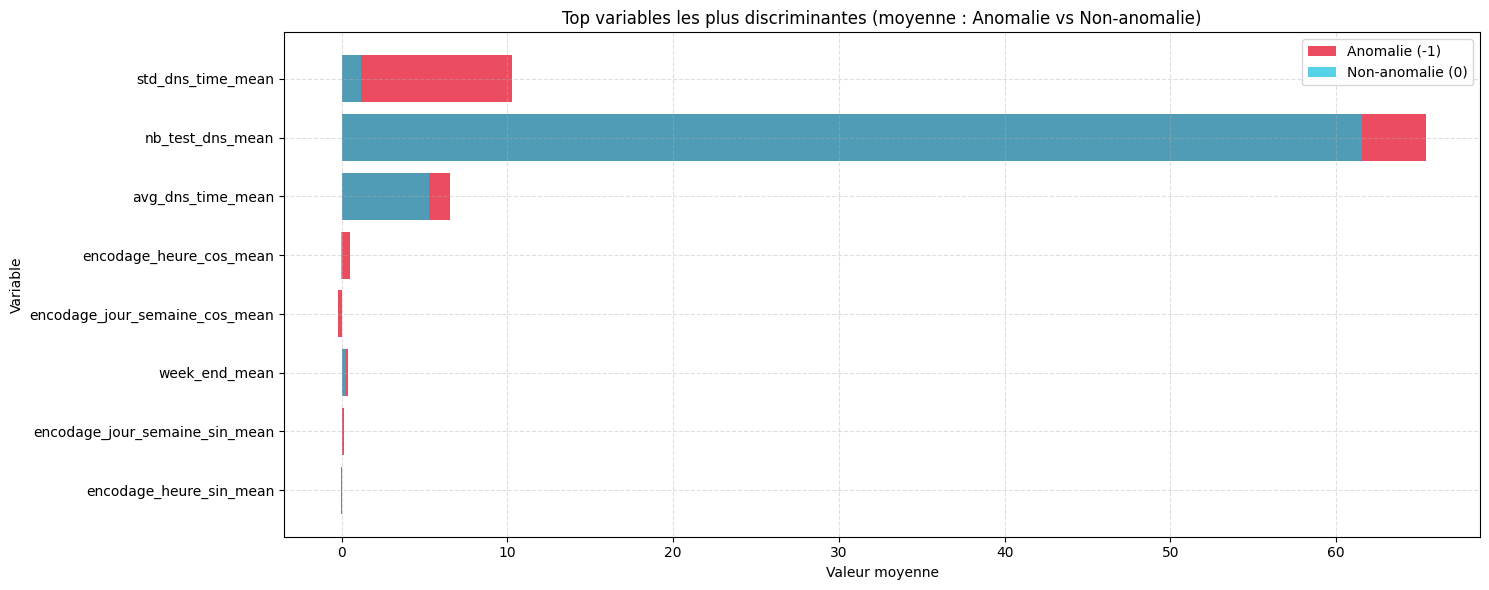

In [31]:
import matplotlib.pyplot as plt

# Étape 1 : Ne garder que les lignes avec des moyennes
mean_only = stats_features[stats_features.index.str.endswith("_mean")].copy()

# Étape 2 : Extraire le cluster -1 (anomalie)
cluster_anomaly = mean_only[-1]

# Étape 3 : Calculer la moyenne de tous les clusters normaux (≠ -1)
cluster_non_anomaly = mean_only[[col for col in mean_only.columns if col != -1]].mean(axis=1)

# Étape 4 : Calculer la différence absolue et trier du plus grand au plus petit
diff = (cluster_anomaly - cluster_non_anomaly).abs().sort_values(ascending=False)
top_features = diff.head(10).index[::-1]  # 🔁 Inverser pour afficher le plus important en haut

# Étape 5 : Préparer le graphique
plt.figure(figsize=(15, 6))

# ✅ Changer les couleurs selon vos codes hex
plt.barh(top_features, cluster_anomaly[top_features], color='#E4001D', alpha=0.7, label='Anomalie (-1)')
plt.barh(top_features, cluster_non_anomaly[top_features], color='#0EBEDB', alpha=0.7, label='Non-anomalie (0)')

# Étape 6 : Mise en forme
plt.title("Top variables les plus discriminantes (moyenne : Anomalie vs Non-anomalie)")
plt.xlabel("Valeur moyenne")
plt.ylabel("Variable")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Étape 1 : Garder uniquement les moyennes
mean_only = stats_features[stats_features.index.str.endswith("_mean")].copy()

# Étape 2 : Extraire les deux clusters -1 et 0
cluster_anomaly = mean_only[-1]
cluster_non_anomaly = mean_only[0]

# Étape 3 : Calculer la différence absolue
diff = (cluster_anomaly - cluster_non_anomaly).abs().sort_values(ascending=False)

# Étape 4 : Prendre les top 10 features
top_features = diff.head(10).index

# Étape 5 : Créer le DataFrame
df_barplot = pd.DataFrame({
    "variable": top_features,
    "valeur_anomalie": cluster_anomaly[top_features].values,
    "valeur_non_anomalie": cluster_non_anomaly[top_features].values,
    "ecart_absolu": diff[top_features].values
})

# Afficher le DataFrame
display(df_barplot)

,variable,valeur_anomalie,valeur_non_anomalie,ecart_absolu
0,std_dns_time_mean,10.289812,1.163708,9.126104
1,nb_test_dns_mean,65.400000,61.555630,3.844370
2,avg_dns_time_mean,6.564818,5.253096,1.311723
3,encodage_heure_cos_mean,0.486370,-0.001640,0.488010
4,encodage_jour_semaine_cos_mean,-0.189008,0.004238,0.193247
5,week_end_mean,0.400000,0.273769,0.126231
6,encodage_jour_semaine_sin_mean,0.125396,0.015355,0.110041
7,encodage_heure_sin_mean,-0.026795,0.000090,0.026885


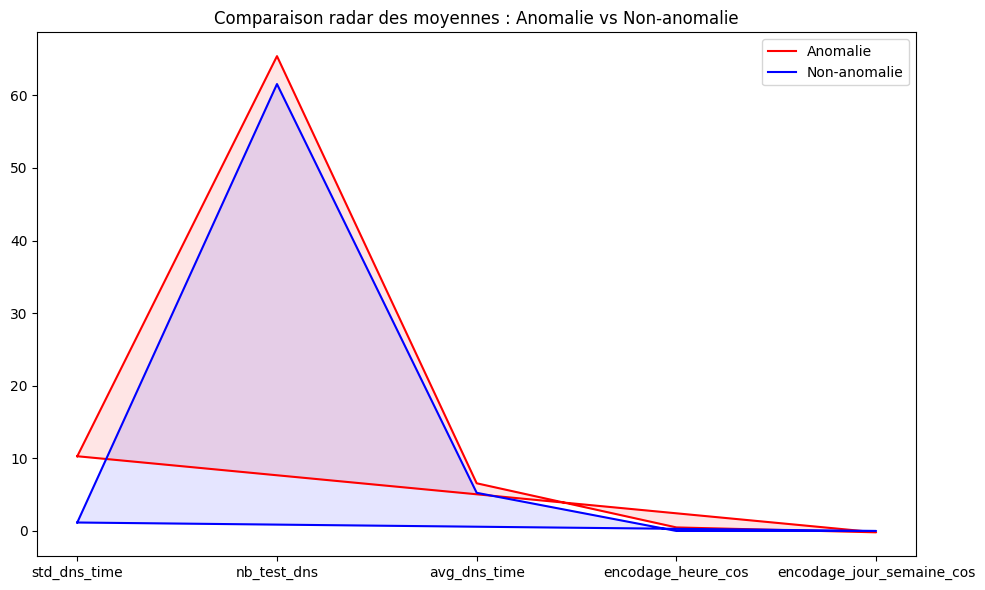

In [ ]:
from math import pi
import pandas as pd
import matplotlib.pyplot as plt

def plot_radar_2_clusters(stats_df, N=5):
    """
    Trace un radar chart pour comparer les moyennes entre Anomalie (-1) et Non-anomalie (0)
    sur les N variables les plus discriminantes.
    """
    # Étape 1 : Filtrer uniquement les moyennes
    mean_only = stats_df[stats_df.index.str.endswith("_mean")].copy()

    # Étape 2 : Calculer l’écart absolu entre Anomalie (-1) et Non-anomalie (0)
    mean_only["diff_score"] = (mean_only[-1] - mean_only[0]).abs()

    # Étape 3 : Sélectionner les N variables les plus discriminantes
    top_N = mean_only.sort_values("diff_score", ascending=False).head(N).drop(columns="diff_score")

    # Étape 4 : Transposer les données pour le radar chart
    df_radar = top_N.T
    df_radar.columns = [name.replace("_mean", "") for name in df_radar.columns]
    categories = list(df_radar.columns)
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]  # Fermer le cercle

    # Étape 5 : Création du graphique
    plt.figure(figsize=(10, 6))

    for cluster, label, color in [(-1, "Anomalie", "red"), (0, "Non-anomalie", "blue")]:
        if cluster in df_radar.index:
            values = df_radar.loc[cluster].tolist()
            values += values[:1]
            plt.plot(angles, values, label=label, color=color)
            plt.fill(angles, values, alpha=0.1, color=color)

    # Étape 6 : Mise en forme
    plt.xticks(angles[:-1], categories, size=10)
    plt.title("Comparaison radar des moyennes : Anomalie vs Non-anomalie")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Appel de la fonction pour visualiser les 5 variables les plus discriminantes
plot_radar_2_clusters(stats_features, N=5)

### Interprétabilité - Feature contributions - PEAG - test_type='scoring'

#### Un exemple de 01_peag_29

In [23]:
# Liste des PEAGs à analyser
peags_test = ["01_peag_29"] # Liste des PEAG

for peag_test in peags_test:
    print(f"Analyse du PEAG : {peag_test}")

    # Étape 0 : Filtrer les données pour ce PEAG
    df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test].copy()

    if df_peag.empty:
        print(f"Aucune donnée pour {peag_test}")
        continue

    # Étape 1 : Appliquer DBSCAN
    df_result = detect_anomalies_dbscan(df=df_peag, test_type="scoring")

    if df_result is None:
        print(f"DBSCAN n’a pas pu être appliqué à {peag_test}")
        continue

    # Étape 2 : Résumer les clusters
    df_summary = summarize_dbscan_clusters(df_result, test_type="scoring")
    display(df_summary)

    # Étape 3 : Analyse des features par cluster
    stats_features = analyze_feature_contributions_dbscan(df_result, test_type="scoring")

    # Étape 4 : Afficher les 10 features les plus discriminantes
    display(stats_features.head(10))

    print("—" * 60)  # Séparation entre PEAGs

Analyse du PEAG : 01_peag_29


,cluster_label,n_points,pct_points (%),description
0,-1,1,0.27,Anomalie (Outlier)
1,0,375,99.73,Cluster normal - Label 0


anomaly_scoring,-1,0
nb_test_scoring_mean,7.000000,6.885333e+00
nb_test_scoring_median,7.000000,7.000000e+00
avg_score_scoring_mean,3.224370,3.463687e+00
avg_score_scoring_median,3.224370,3.475000e+00
std_score_scoring_mean,0.437658,3.403319e-02
std_score_scoring_median,0.437658,4.566541e-03
encodage_heure_sin_mean,-0.866025,-1.543950e-04
encodage_heure_sin_median,-0.866025,1.224647e-16
encodage_heure_cos_mean,-0.500000,-6.200764e-02
encodage_heure_cos_median,-0.500000,-1.836970e-16


————————————————————————————————————————————————————————————


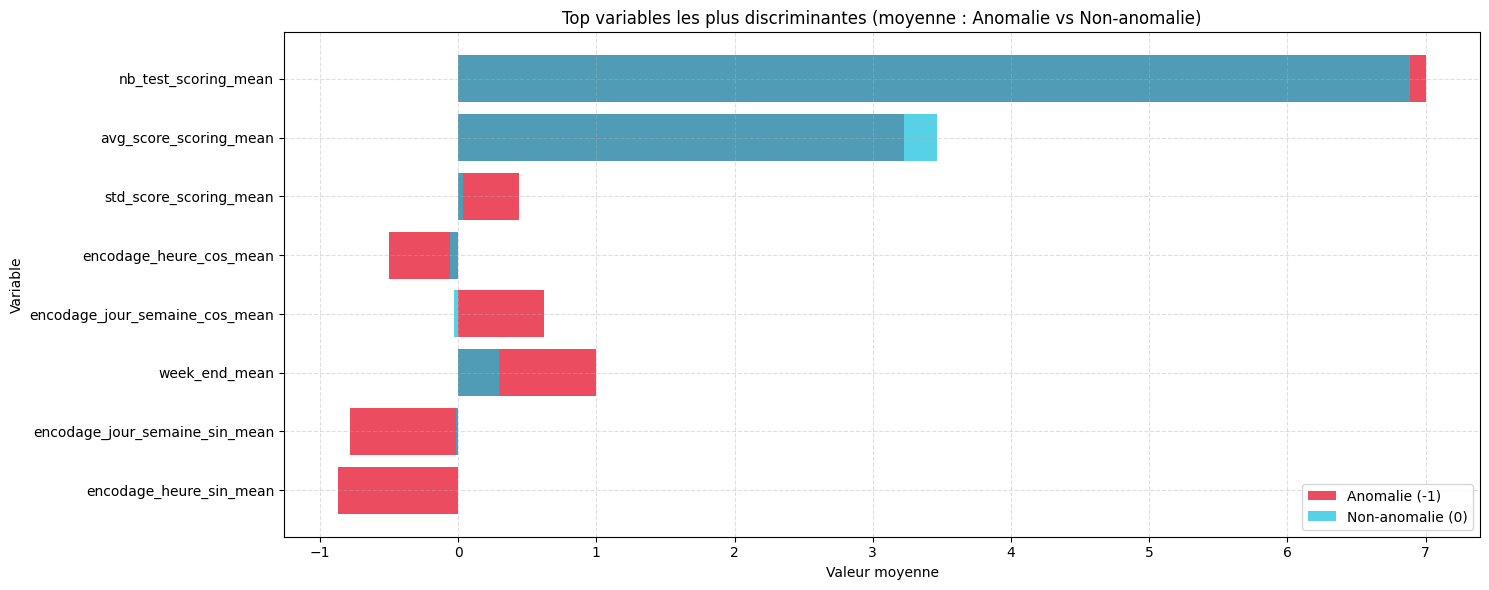

In [25]:
import matplotlib.pyplot as plt

# Étape 1 : Ne garder que les lignes avec des moyennes
mean_only = stats_features[stats_features.index.str.endswith("_mean")].copy()

# Étape 2 : Extraire le cluster -1 (anomalie)
cluster_anomaly = mean_only[-1]

# Étape 3 : Calculer la moyenne de tous les clusters normaux (≠ -1)
cluster_non_anomaly = mean_only[[col for col in mean_only.columns if col != -1]].mean(axis=1)

# Étape 4 : Calculer la différence absolue et trier du plus grand au plus petit
diff = (cluster_anomaly - cluster_non_anomaly).abs().sort_values(ascending=False)
top_features = diff.head(10).index  # 🔽 Affiche du moins au plus important (plus grand en bas)

# Étape 5 : Préparer le graphique
plt.figure(figsize=(15, 6))

# ✅ Changer les couleurs selon vos codes hex
plt.barh(top_features, cluster_anomaly[top_features], color='#E4001D', alpha=0.7, label='Anomalie (-1)')
plt.barh(top_features, cluster_non_anomaly[top_features], color='#0EBEDB', alpha=0.7, label='Non-anomalie (0)')

# Étape 6 : Mise en forme
plt.title("Top variables les plus discriminantes (moyenne : Anomalie vs Non-anomalie)")
plt.xlabel("Valeur moyenne")
plt.ylabel("Variable")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Interprétabilité - Feature contributions - PEAG - test_type='latence'

#### Un exemple de 01_peag_29

In [27]:
# Liste des PEAGs à analyser
peags_test = ["01_peag_29"] # Liste des PEAG

for peag_test in peags_test:
    print(f"Analyse du PEAG : {peag_test}")

    # Étape 0 : Filtrer les données pour ce PEAG
    df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test].copy()

    if df_peag.empty:
        print(f"Aucune donnée pour {peag_test}")
        continue

    # Étape 1 : Appliquer DBSCAN
    df_result = detect_anomalies_dbscan(df=df_peag, test_type="latence")

    if df_result is None:
        print(f"DBSCAN n’a pas pu être appliqué à {peag_test}")
        continue

    # Étape 2 : Résumer les clusters
    df_summary = summarize_dbscan_clusters(df_result, test_type="latence")
    display(df_summary)

    # Étape 3 : Analyse des features par cluster
    stats_features = analyze_feature_contributions_dbscan(df_result, test_type="latence")

    # Étape 4 : Afficher les 10 features les plus discriminantes
    display(stats_features.head(10))

    print("—" * 60)  # Séparation entre PEAGs

Analyse du PEAG : 01_peag_29


,cluster_label,n_points,pct_points (%),description
0,-1,8,2.13,Anomalie (Outlier)
1,0,368,97.87,Cluster normal - Label 0


anomaly_latence,-1,0
nb_test_scoring_mean,6.625000,6.891304e+00
nb_test_scoring_median,6.500000,7.000000e+00
avg_latence_scoring_mean,11.552762,8.531852e+00
avg_latence_scoring_median,11.149554,8.524554e+00
std_latence_scoring_mean,7.808716,3.574711e-01
std_latence_scoring_median,6.942191,2.904738e-01
encodage_heure_sin_mean,-0.183241,1.472832e-03
encodage_heure_sin_median,-0.500000,1.224647e-16
encodage_heure_cos_mean,-0.049099,-6.347846e-02
encodage_heure_cos_median,-0.379410,-1.836970e-16


————————————————————————————————————————————————————————————


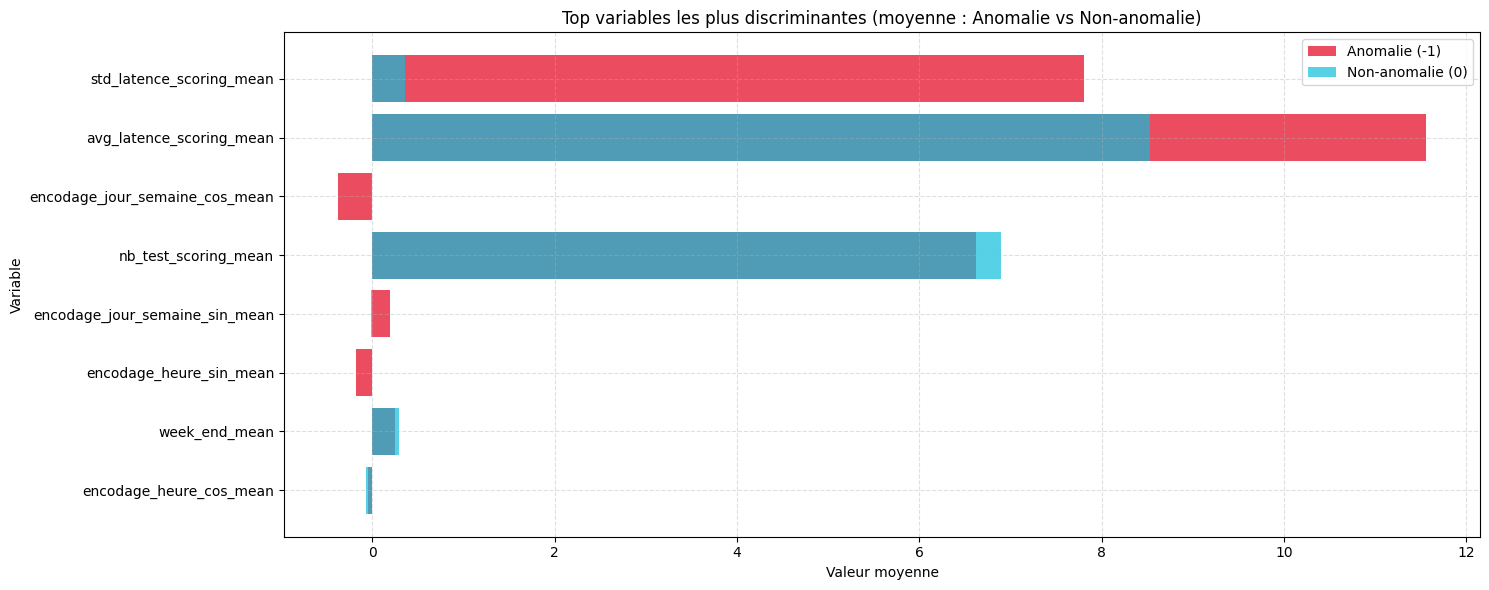

In [29]:
import matplotlib.pyplot as plt

# Étape 1 : Ne garder que les lignes avec des moyennes
mean_only = stats_features[stats_features.index.str.endswith("_mean")].copy()

# Étape 2 : Extraire le cluster -1 (anomalie)
cluster_anomaly = mean_only[-1]

# Étape 3 : Calculer la moyenne de tous les clusters normaux (≠ -1)
cluster_non_anomaly = mean_only[[col for col in mean_only.columns if col != -1]].mean(axis=1)

# Étape 4 : Calculer la différence absolue et trier du plus grand au plus petit
diff = (cluster_anomaly - cluster_non_anomaly).abs().sort_values(ascending=False)
top_features = diff.head(10).index[::-1]  # 🔁 Inverser pour afficher le plus important en haut

# Étape 5 : Préparer le graphique
plt.figure(figsize=(15, 6))

# ✅ Changer les couleurs selon vos codes hex
plt.barh(top_features, cluster_anomaly[top_features], color='#E4001D', alpha=0.7, label='Anomalie (-1)')
plt.barh(top_features, cluster_non_anomaly[top_features], color='#0EBEDB', alpha=0.7, label='Non-anomalie (0)')

# Étape 6 : Mise en forme
plt.title("Top variables les plus discriminantes (moyenne : Anomalie vs Non-anomalie)")
plt.xlabel("Valeur moyenne")
plt.ylabel("Variable")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()